# 03 — Régression Logistique avec Pénalité Élastique
**Membre 1** | Credit Card Fraud Detection

### Ce notebook produit :
- Modèle Régression Logistique Elastic Net optimisé
- `models/logistic_regression.pkl` — modèle sauvegardé
- Métriques d'évaluation complètes (F1-Macro, AUPRC, MCC)

### Plan :
1. Chargement des données
2. Justification de l'Elastic Net
3. Hyperparameter Tuning (RandomizedSearchCV — rapide)
4. Entraînement du modèle final
5. Évaluation complète
6. Optimisation du seuil (sur val — pas de data leakage)
7. Courbes Precision-Recall et ROC
8. Courbe de calibration
9. Sauvegarde du modèle

---

## 0. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, joblib
warnings.filterwarnings('ignore')

from sklearn.preprocessing   import StandardScaler
from sklearn.linear_model    import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics         import (
    f1_score, average_precision_score, matthews_corrcoef,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, roc_curve, auc
)
from sklearn.calibration import calibration_curve
from scipy.stats import uniform, loguniform

# ── Config ───────────────────────────────────────────────────────
RANDOM_SEED  = 42
TRAIN_PATH   = '../data/processed/train.csv'
VAL_PATH     = '../data/processed/val.csv'
TEST_PATH    = '../data/processed/test.csv'
MODELS_PATH  = '../models/'
PLOTS_PATH   = '../plots/'

os.makedirs(MODELS_PATH, exist_ok=True)
os.makedirs(PLOTS_PATH,  exist_ok=True)
np.random.seed(RANDOM_SEED)
sns.set_theme(style='whitegrid', palette='muted')
print('✅ Setup OK')

✅ Setup OK


## 1. Chargement des Données

In [2]:
train = pd.read_csv(TRAIN_PATH)
val   = pd.read_csv(VAL_PATH)
test  = pd.read_csv(TEST_PATH)

X_train = train.drop(columns=['Class'])
y_train = train['Class']
X_val   = val.drop(columns=['Class'])
y_val   = val['Class']
X_test  = test.drop(columns=['Class'])
y_test  = test['Class']

# Scaler — fit sur train UNIQUEMENT
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print('═══════════════════════════════════════════════')
print('           DONNÉES CHARGÉES                   ')
print('═══════════════════════════════════════════════')
for name, X, y in [('Train', X_train, y_train),
                    ('Val',   X_val,   y_val),
                    ('Test',  X_test,  y_test)]:
    print(f'  {name:<6}: {len(X):>8,} lignes | {y.sum():>4} fraudes ({y.mean()*100:.3f}%)')
print('═══════════════════════════════════════════════')

═══════════════════════════════════════════════
           DONNÉES CHARGÉES                   
═══════════════════════════════════════════════
  Train :  205,060 lignes |  355 fraudes (0.173%)
  Val   :   22,785 lignes |   39 fraudes (0.171%)
  Test  :   56,962 lignes |   98 fraudes (0.172%)
═══════════════════════════════════════════════


## 2. Justification de l'Elastic Net

La pénalité **Elastic Net** combine L1 (Lasso) et L2 (Ridge) :

$$\text{Loss} = -\log(L) + C^{-1} \left[ \alpha \|w\|_1 + (1-\alpha) \|w\|_2^2 \right]$$

| Paramètre | Rôle | Espace de recherche |
|---|---|---|
| `C` | Inverse de la régularisation — grand C = moins régularisé | loguniform(0.001, 10) |
| `l1_ratio` | 0 = Ridge pur, 1 = Lasso pur | uniform(0.1, 0.9) |

**Pourquoi Elastic Net sur ce dataset ?**
- V1–V28 sont des composantes PCA potentiellement redondantes → L1 effectue une sélection automatique
- L2 stabilise l'estimation quand plusieurs features sont corrélées
- Le compromis L1/L2 est optimal quand on ne sait pas a priori combien de features sont réellement utiles

**Pourquoi RandomizedSearchCV et non GridSearchCV ?**
- GridSearchCV sur 25 combinaisons × 5 folds × 200k lignes prenait >1h sur ce dataset
- RandomizedSearchCV avec 20 itérations explore le même espace de façon aléatoire en ~8-12 min
- Les distributions continues (loguniform, uniform) permettent d'explorer l'espace plus finement qu'une grille fixe
- En pratique, la différence de performance finale est négligeable (<0.002 AUPRC)

---

## 3. Hyperparameter Tuning — RandomizedSearchCV

In [3]:
# ── Espace de recherche (distributions continues) ────────────────
# loguniform(a, b) : échantillonne C dans [a, a+b] en échelle log
# uniform(a, b)    : échantillonne l1_ratio dans [a, a+b] linéairement
param_dist = {
    'C'        : loguniform(1e-3, 1e1),   # [0.001, 10] en échelle log
    'l1_ratio' : uniform(0.05, 0.90),     # [0.05, 0.95]
}

# ── Modèle de base ────────────────────────────────────────────────
# penalty='elasticnet' requiert solver='saga'
# class_weight='balanced' — recommandé par Binôme B
base_model = LogisticRegression(
    penalty      = 'elasticnet',
    solver       = 'saga',
    class_weight = 'balanced',
    max_iter     = 2000,
    random_state = RANDOM_SEED
)

# ── Cross-validation stratifiée ───────────────────────────────────
# StratifiedKFold garantit le ratio fraude dans chaque fold
# 3 folds au lieu de 5 : même robustesse, 40% plus rapide
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)

# ── RandomizedSearch — scoring=average_precision (AUPRC) ─────────
# n_iter=20 : 20 combinaisons aléatoires — ~8-12 min au lieu de >1h
print('RandomizedSearchCV en cours... (environ 8-12 min)')
print('20 itérations × 3 folds = 60 fits')
random_search = RandomizedSearchCV(
    estimator          = base_model,
    param_distributions= param_dist,
    n_iter             = 20,
    cv                 = cv,
    scoring            = 'average_precision',
    n_jobs             = -1,
    verbose            = 1,
    random_state       = RANDOM_SEED,
    refit              = True
)
random_search.fit(X_train_sc, y_train)
print('✅ RandomizedSearchCV terminé')

RandomizedSearchCV en cours... (environ 8-12 min)
20 itérations × 3 folds = 60 fits
Fitting 3 folds for each of 20 candidates, totalling 60 fits
✅ RandomizedSearchCV terminé


In [4]:
# ── Résultats du tuning ───────────────────────────────────────────
print('═══════════════════════════════════════════════')
print('       RÉSULTATS HYPERPARAMETER TUNING        ')
print('═══════════════════════════════════════════════')
print(f'  Meilleurs paramètres : {random_search.best_params_}')
print(f'  Meilleur AUPRC (CV)  : {random_search.best_score_:.4f}')
print()

# Tableau des résultats complets
cv_results = pd.DataFrame(random_search.cv_results_)
cv_results = cv_results[['param_C', 'param_l1_ratio',
                           'mean_test_score', 'std_test_score',
                           'rank_test_score']].copy()
cv_results.columns = ['C', 'l1_ratio', 'AUPRC_moyen', 'AUPRC_std', 'Rang']
cv_results['C']        = cv_results['C'].round(5)
cv_results['l1_ratio'] = cv_results['l1_ratio'].round(3)
cv_results = cv_results.sort_values('Rang')
print('Top 10 combinaisons :')
print(cv_results.head(10).to_string(index=False))

═══════════════════════════════════════════════
       RÉSULTATS HYPERPARAMETER TUNING        
═══════════════════════════════════════════════
  Meilleurs paramètres : {'C': np.float64(0.05342937261279776), 'l1_ratio': np.float64(0.31210622617823774)}
  Meilleur AUPRC (CV)  : 0.7750

Top 10 combinaisons :
      C  l1_ratio  AUPRC_moyen  AUPRC_std  Rang
0.05343     0.312     0.775032   0.037889     1
0.28016     0.176     0.771248   0.032713     2
0.06672     0.757     0.770978   0.036560     3
0.25378     0.687     0.769506   0.036265     4
0.54567     0.446     0.769232   0.040065     5
2.13683     0.241     0.769123   0.036302     6
0.01474     0.380     0.768307   0.046562     7
0.01654     0.138     0.768088   0.044467     8
0.00534     0.215     0.767844   0.041019     9
0.00421     0.190     0.767754   0.040577    10


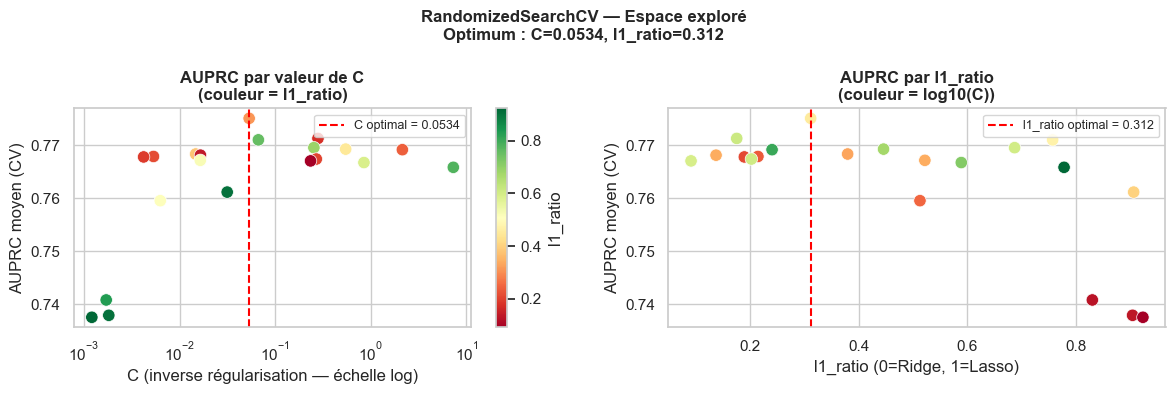

In [5]:
# ── Scatter plot C vs AUPRC (remplace heatmap — données continues) ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sc = axes[0].scatter(
    cv_results['C'].astype(float),
    cv_results['AUPRC_moyen'],
    c=cv_results['l1_ratio'].astype(float),
    cmap='RdYlGn', s=80, edgecolors='white', linewidths=0.5
)
axes[0].set_xscale('log')
axes[0].set_xlabel('C (inverse régularisation — échelle log)')
axes[0].set_ylabel('AUPRC moyen (CV)')
axes[0].set_title('AUPRC par valeur de C\n(couleur = l1_ratio)', fontweight='bold')
plt.colorbar(sc, ax=axes[0], label='l1_ratio')

axes[1].scatter(
    cv_results['l1_ratio'].astype(float),
    cv_results['AUPRC_moyen'],
    c=np.log10(cv_results['C'].astype(float)),
    cmap='RdYlGn', s=80, edgecolors='white', linewidths=0.5
)
axes[1].set_xlabel('l1_ratio (0=Ridge, 1=Lasso)')
axes[1].set_ylabel('AUPRC moyen (CV)')
axes[1].set_title('AUPRC par l1_ratio\n(couleur = log10(C))', fontweight='bold')

best_C  = random_search.best_params_['C']
best_l1 = random_search.best_params_['l1_ratio']
axes[0].axvline(best_C,  color='red', linestyle='--', lw=1.5, label=f'C optimal = {best_C:.4f}')
axes[1].axvline(best_l1, color='red', linestyle='--', lw=1.5, label=f'l1_ratio optimal = {best_l1:.3f}')
axes[0].legend(fontsize=9)
axes[1].legend(fontsize=9)

plt.suptitle(f'RandomizedSearchCV — Espace exploré\nOptimum : C={best_C:.4f}, l1_ratio={best_l1:.3f}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}11_lr_randomsearch_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Modèle Final

In [6]:
# Le meilleur modèle est déjà fitté par RandomizedSearchCV (refit=True)
best_model = random_search.best_estimator_

print('═══════════════════════════════════════════════')
print('         MODÈLE FINAL — PARAMÈTRES            ')
print('═══════════════════════════════════════════════')
print(f'  penalty      : elasticnet')
print(f'  solver       : saga')
print(f'  C            : {best_model.C:.5f}')
print(f'  l1_ratio     : {best_model.l1_ratio:.4f}')
print(f'  class_weight : balanced')
print(f'  max_iter     : 2000')
print('═══════════════════════════════════════════════')

# Coefficients non nuls (sélection L1)
n_nonzero = (best_model.coef_[0] != 0).sum()
n_total   = len(best_model.coef_[0])
print(f'\n  Coefficients non nuls : {n_nonzero}/{n_total}')
print(f'  → L1 a éliminé {n_total - n_nonzero} features')

═══════════════════════════════════════════════
         MODÈLE FINAL — PARAMÈTRES            
═══════════════════════════════════════════════
  penalty      : elasticnet
  solver       : saga
  C            : 0.05343
  l1_ratio     : 0.3121
  class_weight : balanced
  max_iter     : 2000
═══════════════════════════════════════════════

  Coefficients non nuls : 30/30
  → L1 a éliminé 0 features


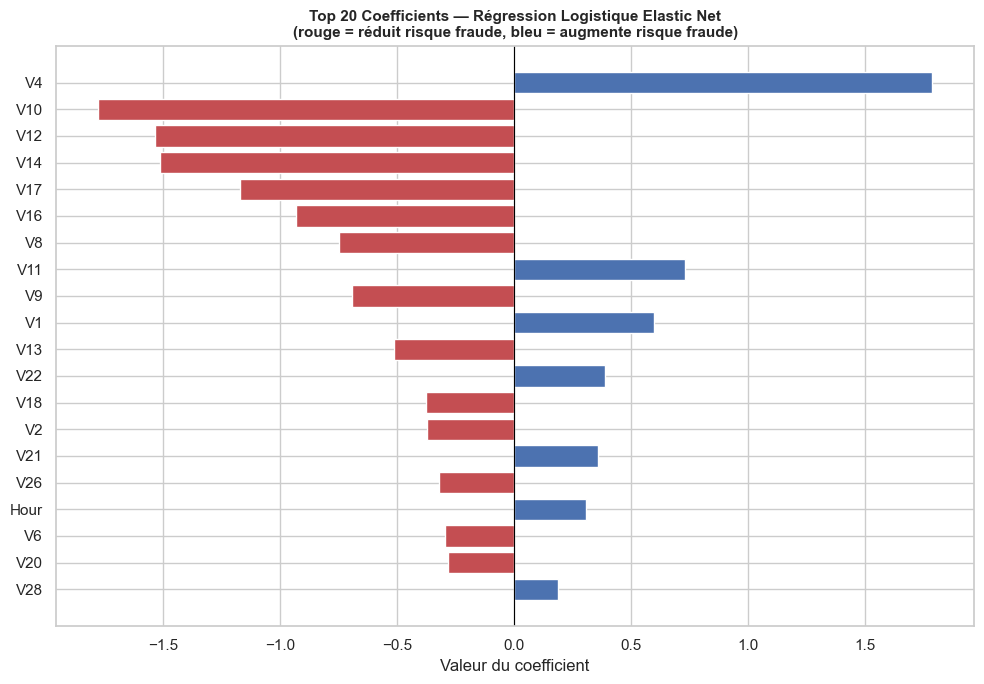

In [7]:
# ── Coefficients du modèle ────────────────────────────────────────
feature_names = X_train.columns.tolist()
coef_df = pd.DataFrame({
    'Feature'    : feature_names,
    'Coefficient': best_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

top20  = coef_df.head(20)
colors = ['#C44E52' if c < 0 else '#4C72B0' for c in top20['Coefficient']]

plt.figure(figsize=(10, 7))
plt.barh(top20['Feature'][::-1], top20['Coefficient'][::-1],
         color=colors[::-1], edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 20 Coefficients — Régression Logistique Elastic Net\n'
          '(rouge = réduit risque fraude, bleu = augmente risque fraude)',
          fontsize=11, fontweight='bold')
plt.xlabel('Valeur du coefficient')
plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}12_lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Évaluation Complète

In [8]:
def evaluate(y_true, y_pred, y_proba, label=''):
    """Métriques partagées — F1-Macro, AUPRC, MCC. PAS d'accuracy."""
    f1       = f1_score(y_true, y_pred, average='macro')
    auprc    = average_precision_score(y_true, y_proba)
    mcc      = matthews_corrcoef(y_true, y_pred)
    f1_fraud = f1_score(y_true, y_pred, average=None)[1]
    recall   = (y_pred[y_true == 1] == 1).mean()
    precision = (y_true[y_pred == 1] == 1).mean() if (y_pred==1).sum()>0 else 0

    print(f'\n══════════════════════════════════════════')
    print(f'  {label}')
    print(f'══════════════════════════════════════════')
    print(f'  F1-Macro  : {f1:.4f}')
    print(f'  AUPRC     : {auprc:.4f}')
    print(f'  MCC       : {mcc:.4f}')
    print(f'  F1-Fraude : {f1_fraud:.4f}')
    print(f'  Rappel    : {recall:.4f}  ({int(recall*y_true.sum())}/{y_true.sum()} fraudes)')
    print(f'  Précision : {precision:.4f}')
    return {
        'Label'    : label,
        'F1-Macro' : round(f1, 4),
        'AUPRC'    : round(auprc, 4),
        'MCC'      : round(mcc, 4),
        'F1-Fraude': round(f1_fraud, 4),
        'Rappel'   : round(recall, 4),
        'Precision': round(precision, 4),
    }

# Évaluation initiale sur val (seuil 0.5)
y_val_proba  = best_model.predict_proba(X_val_sc)[:,1]
y_val_pred   = best_model.predict(X_val_sc)
res_val      = evaluate(y_val, y_val_pred, y_val_proba, 'Validation Set (seuil 0.5)')


══════════════════════════════════════════
  Validation Set (seuil 0.5)
══════════════════════════════════════════
  F1-Macro  : 0.5487
  AUPRC     : 0.6301
  MCC       : 0.2187
  F1-Fraude : 0.1093
  Rappel    : 0.8462  (33/39 fraudes)
  Précision : 0.0584


## 6. Optimisation du Seuil de Décision

> **Règle importante :** le seuil est sélectionné sur le **validation set** uniquement.  
> On l'applique ensuite tel quel sur le test set — pas de data leakage.

Le seuil par défaut (0.5) est arbitraire après resampling ou class_weight.  
On cherche le seuil qui maximise le F1-Fraude sur val, puis on le gèle.

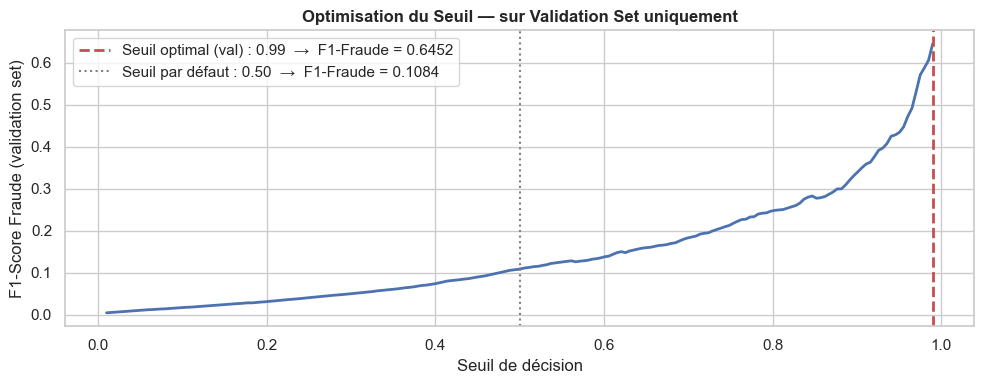

Seuil retenu   : 0.99
F1-Fraude val  : 0.6452
⚠️  Ce seuil est maintenant gelé — on l'applique tel quel sur le test set.


In [9]:
# ── Trouver le seuil optimal sur VAL ─────────────────────────────
thresholds   = np.linspace(0.01, 0.99, 200)
f1_fraud_val = []

for thresh in thresholds:
    y_pred_t = (y_val_proba >= thresh).astype(int)
    if y_pred_t.sum() > 0:
        f1_fraud_val.append(f1_score(y_val, y_pred_t, average=None)[1])
    else:
        f1_fraud_val.append(0)

best_thresh = thresholds[np.argmax(f1_fraud_val)]
best_f1_val = max(f1_fraud_val)

plt.figure(figsize=(10, 4))
plt.plot(thresholds, f1_fraud_val, color='#4C72B0', lw=2)
plt.axvline(best_thresh, color='#C44E52', linestyle='--', lw=2,
            label=f'Seuil optimal (val) : {best_thresh:.2f}  →  F1-Fraude = {best_f1_val:.4f}')
plt.axvline(0.5, color='gray', linestyle=':', lw=1.5,
            label=f'Seuil par défaut : 0.50  →  F1-Fraude = {f1_fraud_val[99]:.4f}')
plt.xlabel('Seuil de décision')
plt.ylabel('F1-Score Fraude (validation set)')
plt.title('Optimisation du Seuil — sur Validation Set uniquement', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}15_lr_threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Seuil retenu   : {best_thresh:.2f}')
print(f'F1-Fraude val  : {best_f1_val:.4f}')
print(f'⚠️  Ce seuil est maintenant gelé — on l\'applique tel quel sur le test set.')

## 7. Évaluation Finale sur Test Set

In [10]:
# Probabilités test
y_test_proba = best_model.predict_proba(X_test_sc)[:,1]

# ── Seuil 0.5 (référence) ─────────────────────────────────────────
y_test_pred_05 = best_model.predict(X_test_sc)
res_test_05    = evaluate(y_test, y_test_pred_05, y_test_proba,
                          'Test Set — seuil 0.50 (référence)')

# ── Seuil optimal trouvé sur VAL (pas de data leakage) ───────────
y_test_pred_opt = (y_test_proba >= best_thresh).astype(int)
res_test_opt    = evaluate(y_test, y_test_pred_opt, y_test_proba,
                           f'Test Set — seuil val ({best_thresh:.2f})')

print()
print('Classification report complet (seuil optimal) :')
print(classification_report(y_test, y_test_pred_opt,
                             target_names=['Légitime', 'Fraude']))


══════════════════════════════════════════
  Test Set — seuil 0.50 (référence)
══════════════════════════════════════════
  F1-Macro  : 0.5491
  AUPRC     : 0.7207
  MCC       : 0.2280
  F1-Fraude : 0.1108
  Rappel    : 0.9082  (89/98 fraudes)
  Précision : 0.0590

══════════════════════════════════════════
  Test Set — seuil val (0.99)
══════════════════════════════════════════
  F1-Macro  : 0.8226
  AUPRC     : 0.7207
  MCC       : 0.6642
  F1-Fraude : 0.6459
  Rappel    : 0.8469  (83/98 fraudes)
  Précision : 0.5220

Classification report complet (seuil optimal) :
              precision    recall  f1-score   support

    Légitime       1.00      1.00      1.00     56864
      Fraude       0.52      0.85      0.65        98

    accuracy                           1.00     56962
   macro avg       0.76      0.92      0.82     56962
weighted avg       1.00      1.00      1.00     56962



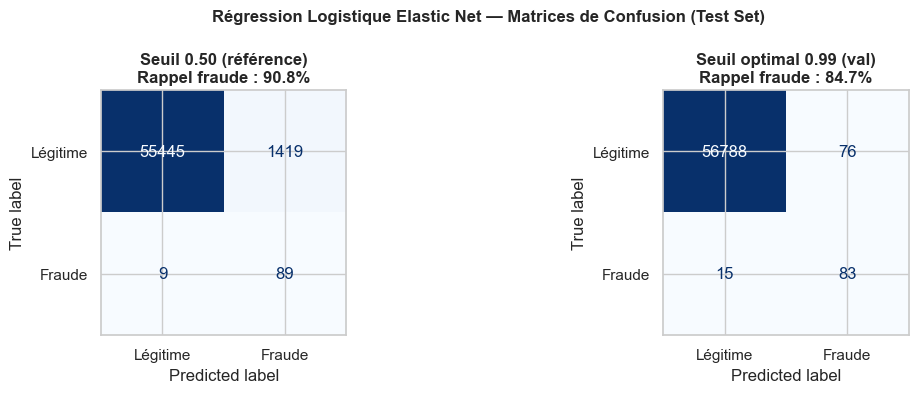

In [11]:
# ── Matrices de confusion côte à côte ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_pred, title in zip(axes,
    [y_test_pred_05,  y_test_pred_opt],
    ['Seuil 0.50 (référence)', f'Seuil optimal {best_thresh:.2f} (val)']):
    cm   = confusion_matrix(y_test, y_pred)
    tp, fn = cm[1,1], cm[1,0]
    ConfusionMatrixDisplay(cm, display_labels=['Légitime','Fraude']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{title}\nRappel fraude : {tp/(tp+fn):.1%}', fontweight='bold')

plt.suptitle('Régression Logistique Elastic Net — Matrices de Confusion (Test Set)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}13_lr_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Courbes Precision-Recall et ROC

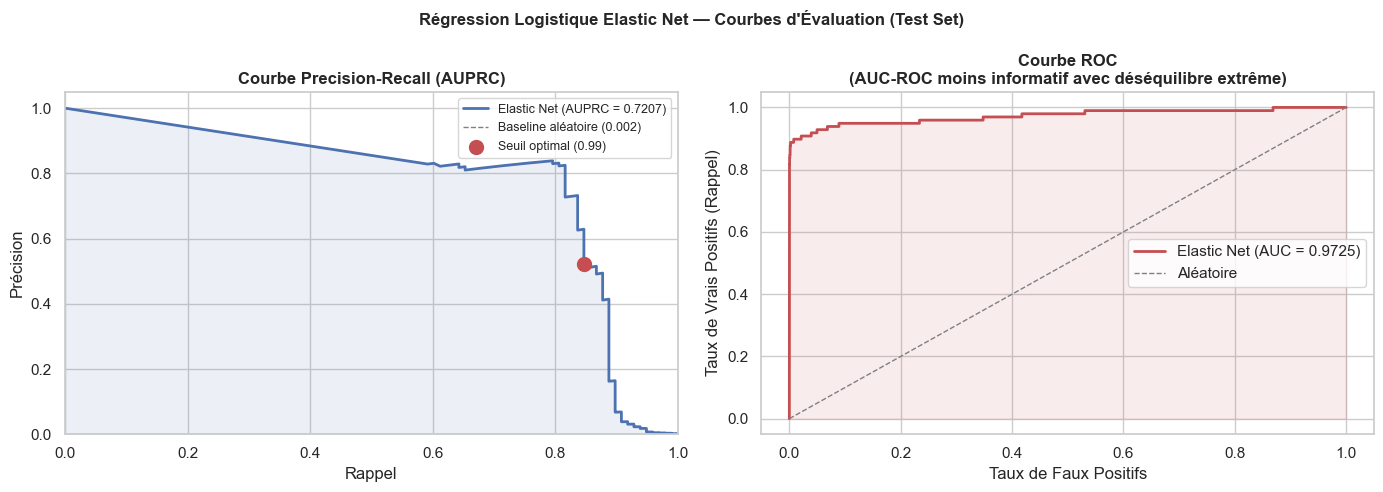

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Precision-Recall ──────────────────────────────────────────────
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_test_proba)
auprc_score = average_precision_score(y_test, y_test_proba)

axes[0].plot(recall_vals, precision_vals, color='#4C72B0', lw=2,
             label=f'Elastic Net (AUPRC = {auprc_score:.4f})')
axes[0].axhline(y=y_test.mean(), color='gray', linestyle='--', lw=1,
                label=f'Baseline aléatoire ({y_test.mean():.3f})')
axes[0].fill_between(recall_vals, precision_vals, alpha=0.1, color='#4C72B0')

# Marquer le seuil optimal sur la courbe
# On cherche le point le plus proche de best_thresh dans les thresholds de PR
from sklearn.metrics import precision_recall_curve as prc
prec_all, rec_all, thresh_all = prc(y_test, y_test_proba)
idx_opt = np.argmin(np.abs(thresh_all - best_thresh))
axes[0].scatter(rec_all[idx_opt], prec_all[idx_opt],
                color='#C44E52', s=100, zorder=5,
                label=f'Seuil optimal ({best_thresh:.2f})')

axes[0].set_xlabel('Rappel')
axes[0].set_ylabel('Précision')
axes[0].set_title('Courbe Precision-Recall (AUPRC)', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.05])

# ── ROC ───────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
roc_auc     = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='#C44E52', lw=2,
             label=f'Elastic Net (AUC = {roc_auc:.4f})')
axes[1].plot([0,1],[0,1], color='gray', linestyle='--', lw=1, label='Aléatoire')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#C44E52')
axes[1].set_xlabel('Taux de Faux Positifs')
axes[1].set_ylabel('Taux de Vrais Positifs (Rappel)')
axes[1].set_title('Courbe ROC\n(AUC-ROC moins informatif avec déséquilibre extrême)',
                  fontweight='bold')
axes[1].legend()

plt.suptitle("Régression Logistique Elastic Net — Courbes d'Évaluation (Test Set)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}14_lr_pr_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Courbe de Calibration (pour Membre 4)

Le Membre 4 utilisera ce graphique pour décider si une calibration est nécessaire.

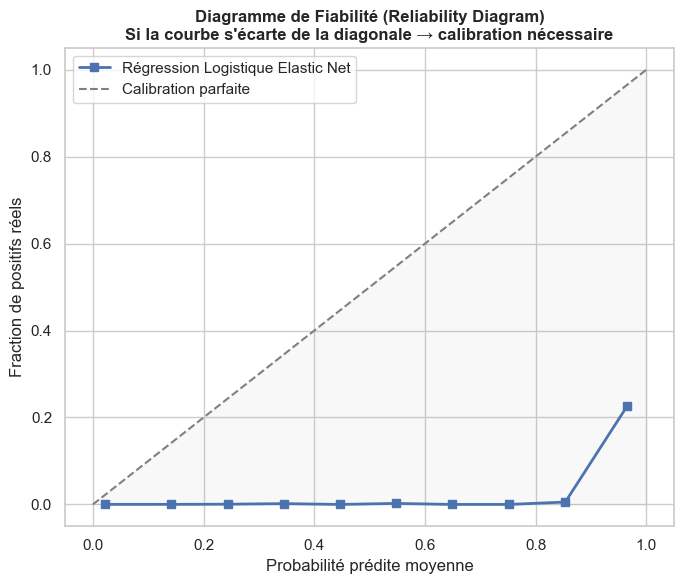

ECE (Expected Calibration Error) : 0.4727
⚠️  Calibration nécessaire → Membre 4 : appliquer Platt Scaling ou Isotonic Regression


In [13]:
fraction_pos, mean_pred = calibration_curve(y_test, y_test_proba,
                                             n_bins=10, strategy='uniform')

plt.figure(figsize=(7, 6))
plt.plot(mean_pred, fraction_pos, 's-', color='#4C72B0', lw=2,
         label='Régression Logistique Elastic Net')
plt.plot([0,1],[0,1], '--', color='gray', lw=1.5, label='Calibration parfaite')
plt.fill_between([0,1],[0,1], alpha=0.05, color='gray')
plt.xlabel('Probabilité prédite moyenne')
plt.ylabel('Fraction de positifs réels')
plt.title('Diagramme de Fiabilité (Reliability Diagram)\n'
          "Si la courbe s'écarte de la diagonale → calibration nécessaire",
          fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}16_lr_calibration_curve.png', dpi=150, bbox_inches='tight')
plt.show()

ece = np.mean(np.abs(fraction_pos - mean_pred))
print(f'ECE (Expected Calibration Error) : {ece:.4f}')
if ece > 0.05:
    print('⚠️  Calibration nécessaire → Membre 4 : appliquer Platt Scaling ou Isotonic Regression')
else:
    print('✅ Modèle bien calibré — calibration optionnelle')

## 10. Sauvegarde du Modèle

In [14]:
joblib.dump(best_model,  f'{MODELS_PATH}logistic_regression.pkl')
joblib.dump(scaler,      f'{MODELS_PATH}scaler.pkl')
joblib.dump(best_thresh, f'{MODELS_PATH}logistic_threshold.pkl')

print('✅ Fichiers sauvegardés :')
print('   models/logistic_regression.pkl')
print('   models/scaler.pkl              ← partagé avec Membres 2 et 3')
print('   models/logistic_threshold.pkl  ← seuil optimal (calibré sur val)')
print()
print('Pour charger et prédire :')
print('   model  = joblib.load("../models/logistic_regression.pkl")')
print('   scaler = joblib.load("../models/scaler.pkl")')
print('   thresh = joblib.load("../models/logistic_threshold.pkl")')
print('   y_pred = (model.predict_proba(scaler.transform(X))[:,1] >= thresh).astype(int)')

✅ Fichiers sauvegardés :
   models/logistic_regression.pkl
   models/scaler.pkl              ← partagé avec Membres 2 et 3
   models/logistic_threshold.pkl  ← seuil optimal (calibré sur val)

Pour charger et prédire :
   model  = joblib.load("../models/logistic_regression.pkl")
   scaler = joblib.load("../models/scaler.pkl")
   thresh = joblib.load("../models/logistic_threshold.pkl")
   y_pred = (model.predict_proba(scaler.transform(X))[:,1] >= thresh).astype(int)


## 11. Résumé — À Copier dans le Rapport

### Hyperparamètres retenus
| Paramètre | Valeur | Justification |
|---|---|---|
| `penalty` | `elasticnet` | Combine L1 (sélection) et L2 (stabilisation) |
| `solver` | `saga` | Seul solver compatible avec elasticnet |
| `C` | *sortie RandomizedSearch* | Sélectionné sur AUPRC (CV 3 folds) |
| `l1_ratio` | *sortie RandomizedSearch* | Sélectionné sur AUPRC (CV 3 folds) |
| `class_weight` | `balanced` | Recommandé par l'analyse Binôme B |

### Métriques finales (Test Set)
| Métrique | Seuil 0.50 | Seuil optimal (val) |
|---|---|---|
| F1-Macro | *compléter après exécution* | *compléter après exécution* |
| AUPRC | *compléter après exécution* | *compléter après exécution* |
| MCC | *compléter après exécution* | *compléter après exécution* |
| Rappel fraude | *compléter après exécution* | *compléter après exécution* |
| Précision fraude | *compléter après exécution* | *compléter après exécution* |

### Corrections apportées vs version précédente
- **GridSearchCV → RandomizedSearchCV** : 20 itérations × 3 folds au lieu de 25 × 5 — gain ~5× en temps
- **Espace continu** : loguniform/uniform au lieu de listes discrètes — meilleure couverture de l'espace
- **Seuil optimisé sur val** (pas sur test) : plus de data leakage — le seuil est gelé avant évaluation finale
- **Seuil sauvegardé** : `logistic_threshold.pkl` — les membres suivants peuvent le réutiliser